In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder 


In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
#Drop ID or known target column if present 
df.drop(columns = ["CustomerID","Genre"], inplace= True  )

In [4]:
#encode categorical column
cat_cols = df.select_dtypes(
    include = ["object", "category"]).columns.tolist()
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str)) 

In [5]:
#scale features -mandatory 
scaler = StandardScaler()
X_scaled  = scaler.fit_transform(df.values)

print("Dataset shape :", df.shape)
print("Features used :", df.columns.tolist())


Dataset shape : (200, 3)
Features used : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [6]:
import matplotlib.pyplot as plt 
from sklearn.cluster import AgglomerativeClustering 
from scipy.cluster.hierarchy import dendrogram

SECTION 1 DENDOGRAM

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
 
def sklearn_linkage_matrix(model):
    """
    Convert sklearn AgglomerativeClustering merge tree into
    a scipy-compatible linkage matrix Z of shape (n-1, 4).
    Each row: [cluster_a, cluster_b, distance, new_size]
    """
    n_samples = model.n_leaves_
    counts     = np.zeros(model.children_.shape[0])
    cluster_sizes = {i: 1 for i in range(n_samples)}
 
    for i, (left, right) in enumerate(model.children_):
        size_left  = cluster_sizes.get(left,  1)
        size_right = cluster_sizes.get(right, 1)
        counts[i]  = size_left + size_right
        cluster_sizes[n_samples + i] = counts[i]
 
    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)
    return linkage_matrix


In [8]:
#1a Fit AgglomerativeClustering to extract merge tree 
#   n_clusters = None + distance_threshold=0 forces the algorightm to build the tree (all merges). 
agg_full = AgglomerativeClustering(
    n_clusters =None, 
    distance_threshold= 0,       #Build full tree 
    linkage = "ward",             # "ward", "complete", "average", "single"
    compute_distances = True      # Require to get distances 
)
agg_full.fit(X_scaled)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",True


In [9]:
# ── 1b. Build linkage matrix from sklearn merge tree ─────────
Z = sklearn_linkage_matrix(agg_full)
 
print(f"Linkage matrix shape : {Z.shape}  (one row per merge)")
print(f"Leaves               : {agg_full.n_leaves_}")
print(f"\nFirst 5 merges:")
print(f"{'Cluster A':>12} {'Cluster B':>12} {'Distance':>12} {'Size':>8}")
print("-" * 50)
for row in Z[:5]:
    print(f"{int(row[0]):>12} {int(row[1]):>12}"
          f" {row[2]:>12.4f} {int(row[3]):>8}")


Linkage matrix shape : (199, 4)  (one row per merge)
Leaves               : 200

First 5 merges:
   Cluster A    Cluster B     Distance     Size
--------------------------------------------------
          65           68       0.0718        2
         129          131       0.0718        2
         106          109       0.0776        2
           3            5       0.0901        2
          92           96       0.1057        2


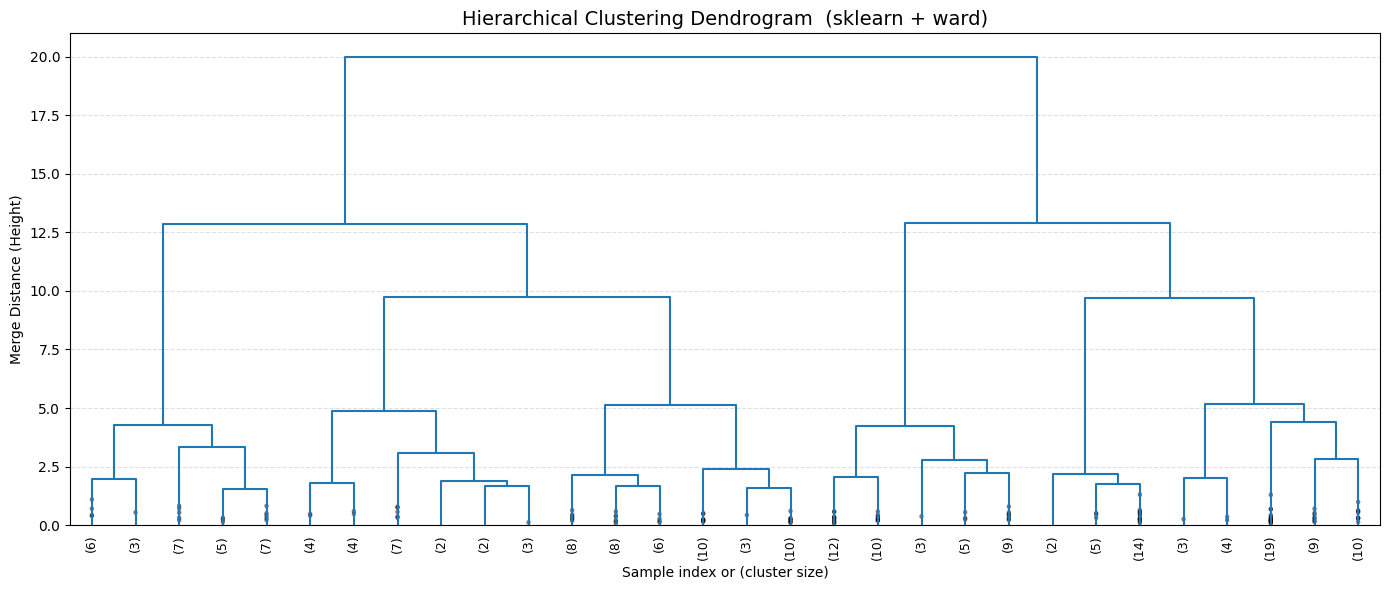

In [10]:
# ── 1c. Plot full dendrogram 
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',   # Show only last p merges
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=0
)
ax.set_title("Hierarchical Clustering Dendrogram  (sklearn + ward)",
             fontsize=14)
ax.set_xlabel("Sample index or (cluster size)")
ax.set_ylabel("Merge Distance (Height)")
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("sklearn_dendrogram_full.png", dpi=150)
plt.show()


FINDING THE BEST CUT 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
 
merge_distances = Z[:, 2]          # All merge distances from Z
 
# ── Method A: Largest Gap 
gaps          = np.diff(merge_distances)
best_gap_idx  = np.argmax(gaps)
best_height   = (merge_distances[best_gap_idx] +
                 merge_distances[best_gap_idx + 1]) / 2
best_k_gap    = len(merge_distances) - best_gap_idx
 
print("=== Method A: Largest Gap ===")
print(f"  Gap magnitude      : {gaps.max():.4f}")
print(f"  Best cut height    : {best_height:.4f}")
print(f"  Implied K          : {best_k_gap}")
 



=== Method A: Largest Gap ===
  Gap magnitude      : 7.0941
  Best cut height    : 16.4530
  Implied K          : 2


In [12]:
# ── Method B: Acceleration Curve (2nd derivative) ────────────
last_k       = 15
rev_dists    = merge_distances[::-1]
accel        = np.diff(rev_dists, 2)
best_k_accel = int(accel[:last_k].argmax()) + 2
 
print("\n=== Method B: Acceleration Curve ===")
print(f"  Best K             : {best_k_accel}")



=== Method B: Acceleration Curve ===
  Best K             : 2


In [13]:
# ── Choose final K 
# Use largest-gap result; override manually if needed
best_k = best_k_gap
print(f"\n>>> Final chosen K  : {best_k}")
print(f">>> Final cut height: {best_height:.4f}")



>>> Final chosen K  : 2
>>> Final cut height: 16.4530


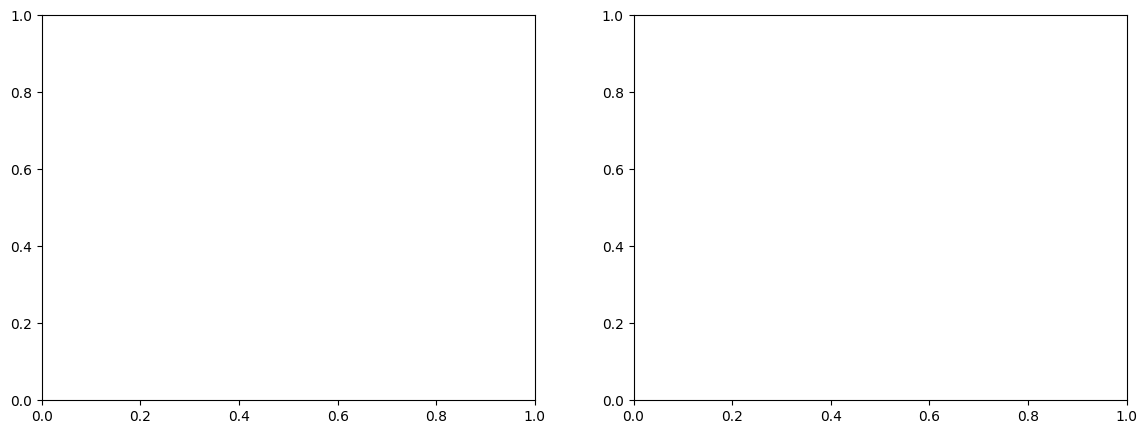

In [14]:
# ── Plot: Merge distances with gap highlighted ────────────────
last_n = min(20, len(merge_distances))
steps  = range(len(merge_distances) - last_n, len(merge_distances))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


In [15]:
# Left: merge distance curve
ax1 = axes[0]
ax1.plot(list(steps), merge_distances[-last_n:],
         marker='o', color='steelblue', linewidth=1.8, markersize=6)
ax1.axhline(y=best_height, color='crimson', linewidth=2,
            linestyle='--', label=f'Cut height = {best_height:.2f}')
ax1.axhspan(merge_distances[best_gap_idx],
            merge_distances[best_gap_idx + 1],
            alpha=0.2, color='crimson', label='Largest gap')
ax1.set_title("Merge Distances — Last 20 Merges")
ax1.set_xlabel("Merge step")
ax1.set_ylabel("Distance")
ax1.legend()
ax1.grid(linestyle='--', alpha=0.4)


In [16]:
# Right: acceleration curve
ax2 = axes[1]
ax2.plot(range(2, last_k + 2), accel[:last_k],
         marker='s', color='darkorange', linewidth=1.8, markersize=6)
ax2.axvline(best_k_accel, color='crimson', linewidth=2,
            linestyle='--', label=f'Best K = {best_k_accel}')
ax2.set_title("Acceleration Curve (2nd Derivative)")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Acceleration")
ax2.legend()
ax2.grid(linestyle='--', alpha=0.4)
 
plt.suptitle("Best Cut Height Analysis", fontsize=13)
plt.tight_layout()
plt.savefig("sklearn_best_height.png", dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

In [17]:
# Fit with the best K determined in Section 2
model = AgglomerativeClustering(
    n_clusters=best_k,         # Final K from best-height analysis
    linkage='ward',            # Match the linkage used for the tree
    metric='euclidean',        # Distance metric
    compute_distances=False    # Not needed for final model
)
labels = model.fit_predict(X_scaled)


In [18]:
# Assign labels to dataframe
# Note: sklearn labels are 0-indexed (unlike scipy fcluster)
df['Cluster'] = labels
 
print(f"Model              : AgglomerativeClustering")
print(f"Linkage            : {model.linkage}")
print(f"n_clusters         : {model.n_clusters_}")
print(f"n_leaves           : {model.n_leaves_}")
print(f"n_connected_components: {model.n_connected_components_}")
print(f"\nCluster Counts:")
print(df['Cluster'].value_counts().sort_index().to_string())


Model              : AgglomerativeClustering
Linkage            : ward
n_clusters         : 2
n_leaves           : 200
n_connected_components: 1

Cluster Counts:
Cluster
0    105
1     95


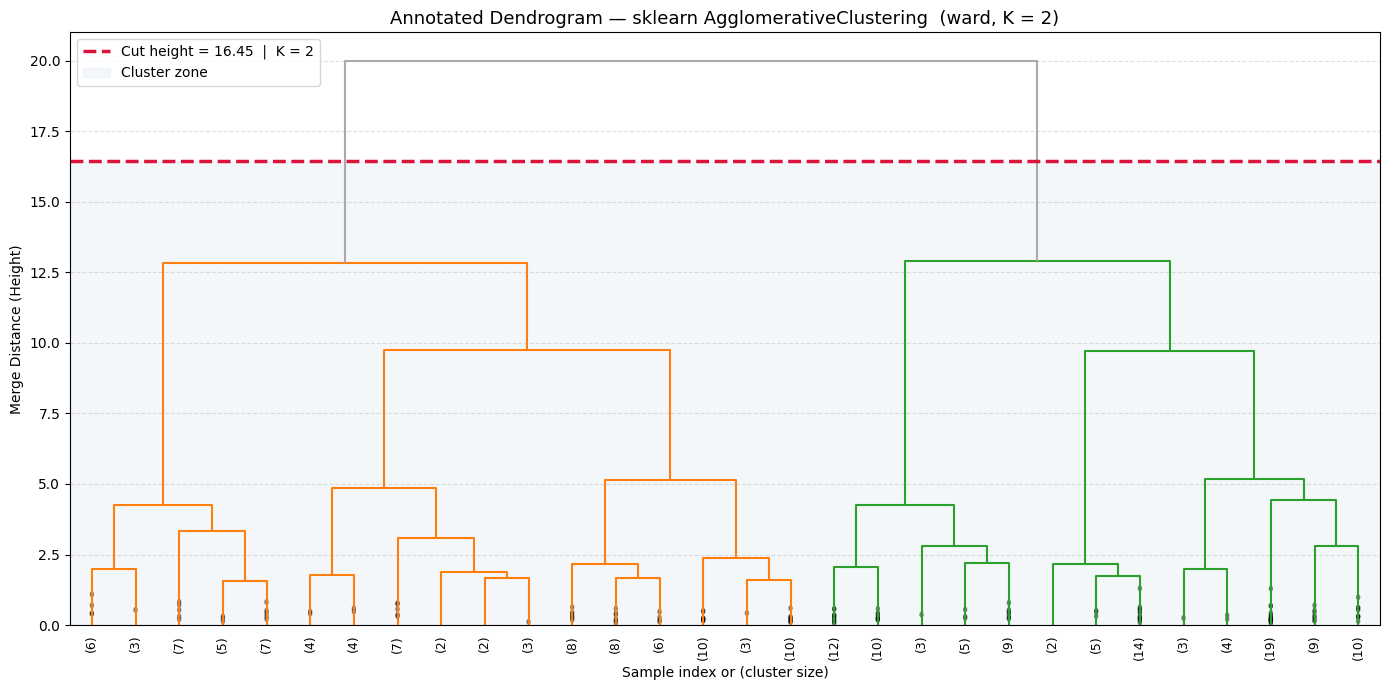

In [19]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
 
fig, ax = plt.subplots(figsize=(14, 7))
 
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=best_height,      # Colour branches by cluster
    above_threshold_color='#AAAAAA'   # Gray for merged portion
)
 
# Cut line
ax.axhline(y=best_height, color='crimson', linewidth=2.5,
           linestyle='--',
           label=f'Cut height = {best_height:.2f}  |  K = {best_k}')
 
# Shaded cluster zone (below the cut)
ax.axhspan(0, best_height, alpha=0.06, color='steelblue',
           label='Cluster zone')
 
ax.set_title(
    f"Annotated Dendrogram — sklearn AgglomerativeClustering"
    f"  (ward, K = {best_k})",
    fontsize=13
)
ax.set_xlabel("Sample index or (cluster size)")
ax.set_ylabel("Merge Distance (Height)")
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("sklearn_dendrogram_annotated.png", dpi=150)
plt.show()
 


CLUSTER PROFILING 

In [20]:
import seaborn as sns
 
feat_cols = [c for c in df.columns if c != 'Cluster']
 
# 5a. Cluster counts
print("\n--- Cluster Sizes ---")
print(df['Cluster'].value_counts().sort_index().to_string())
 



--- Cluster Sizes ---
Cluster
0    105
1     95


In [21]:
# 5b. Cluster means (original scale)
cluster_means = df.groupby('Cluster').mean().round(3)
print("\n--- Cluster Means ---")
print(cluster_means.to_string())



--- Cluster Means ---
            Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                    
0        28.838              61.914                  66.200
1        49.916              59.063                  32.516


In [22]:
# 5c. Full descriptive stats per cluster
print("\n--- Descriptive Statistics by Cluster ---")
for c in sorted(df['Cluster'].unique()):
    n = (df['Cluster'] == c).sum()
    print(f"\n  Cluster {c}  (n = {n})")
    print(df[df['Cluster'] == c].describe().round(3).to_string())



--- Descriptive Statistics by Cluster ---

  Cluster 0  (n = 105)
           Age  Annual Income (k$)  Spending Score (1-100)  Cluster
count  105.000             105.000                 105.000    105.0
mean    28.838              61.914                  66.200      0.0
std      6.704              25.864                  21.198      0.0
min     18.000              15.000                   5.000      0.0
25%     23.000              42.000                  52.000      0.0
50%     29.000              64.000                  72.000      0.0
75%     33.000              78.000                  83.000      0.0
max     45.000             137.000                  99.000      0.0

  Cluster 1  (n = 95)
          Age  Annual Income (k$)  Spending Score (1-100)  Cluster
count  95.000              95.000                  95.000     95.0
mean   49.916              59.063                  32.516      1.0
std    11.298              26.758                  17.680      0.0
min    19.000              15.

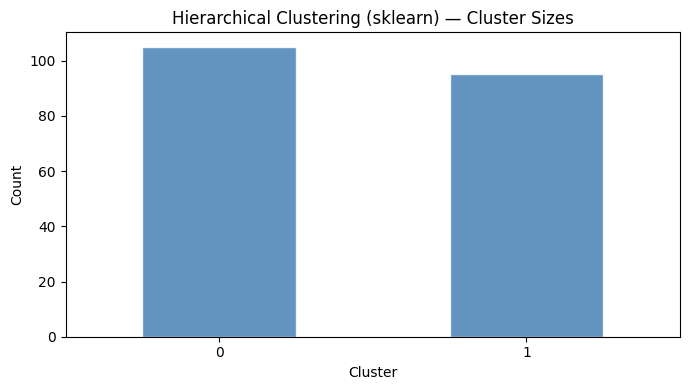

In [23]:
# 5d. Cluster size bar chart
plt.figure(figsize=(7, 4))
df['Cluster'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', alpha=0.85, edgecolor='white')
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Hierarchical Clustering (sklearn) — Cluster Sizes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sklearn_cluster_sizes.png", dpi=150)
plt.show()


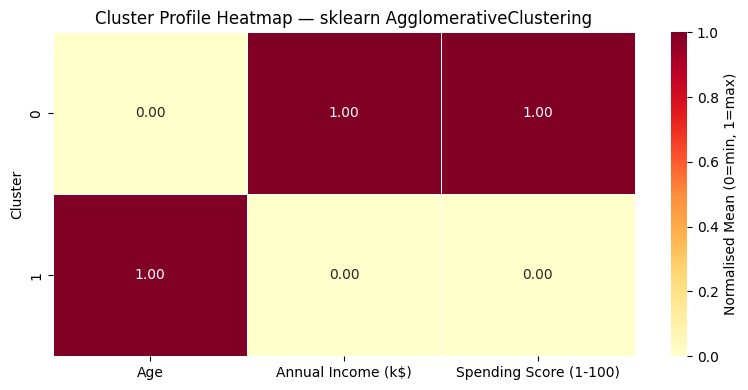

In [24]:
# 5e. Normalised heatmap of cluster means
norm_means = cluster_means[feat_cols].copy()
for col in feat_cols:
    col_min, col_max = norm_means[col].min(), norm_means[col].max()
    if col_max > col_min:
        norm_means[col] = (norm_means[col] - col_min) / (col_max - col_min)
 
plt.figure(figsize=(max(8, len(feat_cols) * 0.9), 4))
sns.heatmap(norm_means, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5,
            cbar_kws={'label': 'Normalised Mean (0=min, 1=max)'})
plt.title("Cluster Profile Heatmap — sklearn AgglomerativeClustering")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("sklearn_profile_heatmap.png", dpi=150)
plt.show()


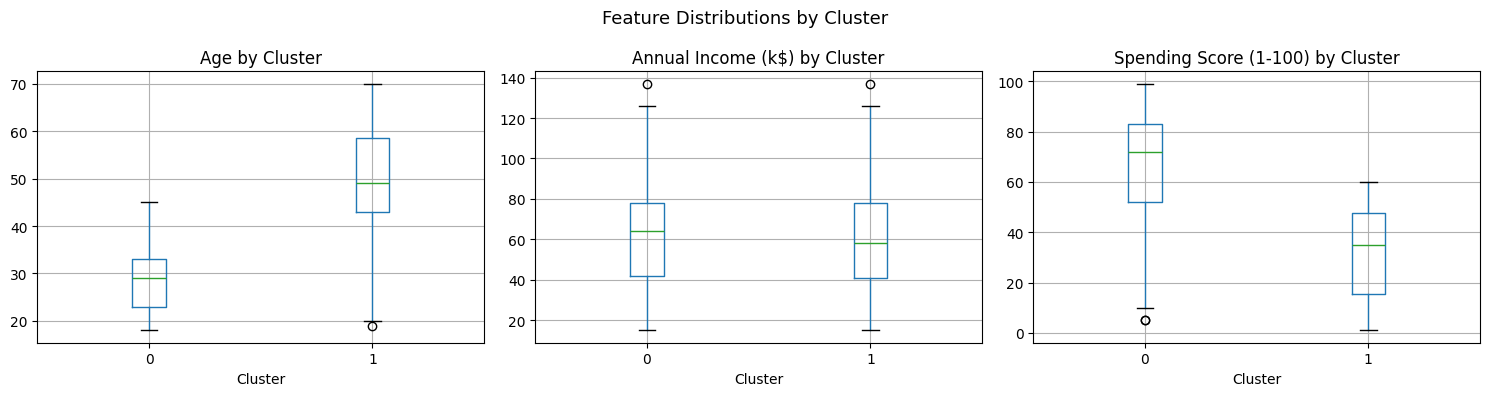

In [25]:
# 5f. Box plots — each feature split by cluster
n_feat = len(feat_cols)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten() if n_feat > 1 else [axes]
for i, col in enumerate(feat_cols):
    df.boxplot(column=col, by='Cluster', ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Feature Distributions by Cluster", fontsize=13)
plt.tight_layout()
plt.savefig("sklearn_boxplots_by_cluster.png", dpi=150)
plt.show()


CLUSTER VISUALIZATION

In [26]:
from sklearn.decomposition import PCA
 
palette = plt.cm.get_cmap('Set2', best_k)


C:\Users\USER\AppData\Local\Temp\ipykernel_24200\4257739883.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('Set2', best_k)


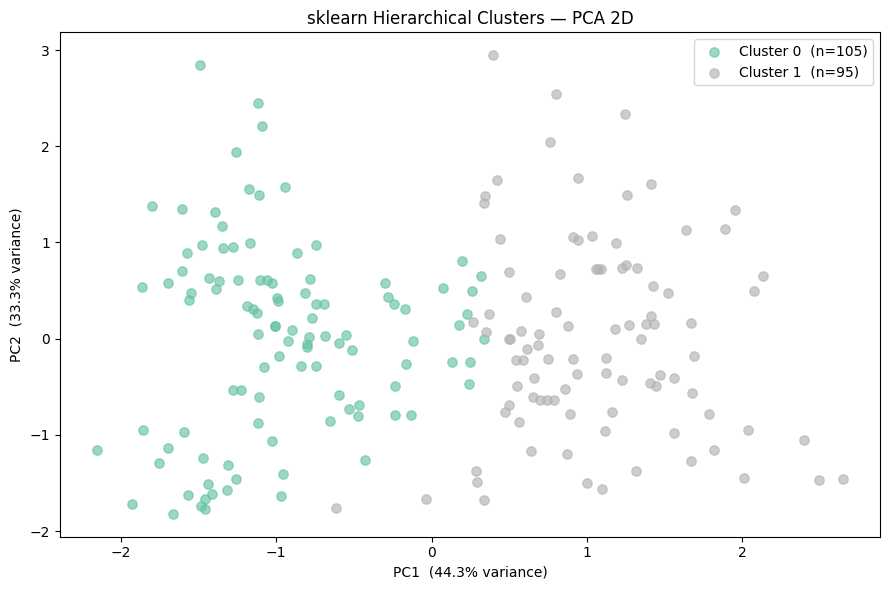

In [27]:
# ── 6a. PCA 2D scatter ───────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)
var2 = pca2.explained_variance_ratio_ * 100
 
plt.figure(figsize=(9, 6))
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=palette(c), alpha=0.65, s=45,
                label=f'Cluster {c}  (n={mask.sum()})')
plt.xlabel(f'PC1  ({var2[0]:.1f}% variance)')
plt.ylabel(f'PC2  ({var2[1]:.1f}% variance)')
plt.title("sklearn Hierarchical Clusters — PCA 2D")
plt.legend()
plt.tight_layout()
plt.savefig("sklearn_pca2d.png", dpi=150)
plt.show()
 


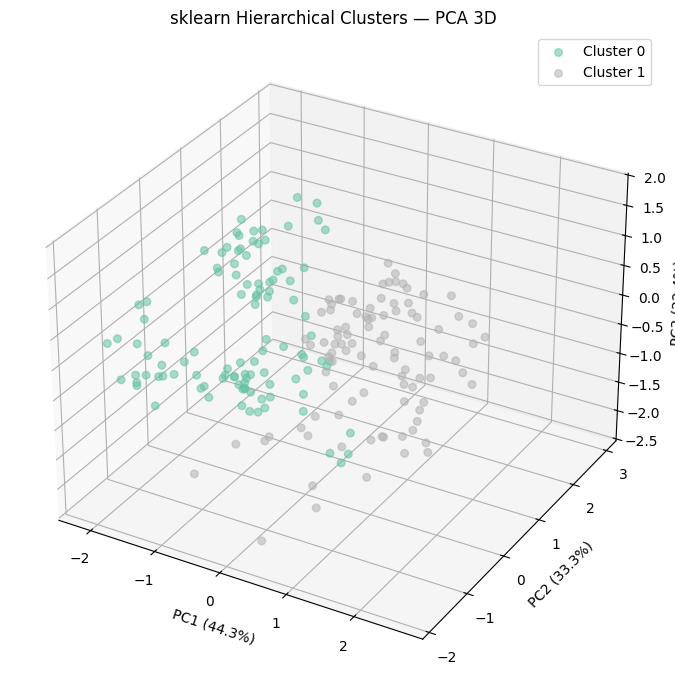

Total variance (3 PCs): 100.0%


In [28]:
# ── 6b. PCA 3D scatter ───────────────────────────────────────
pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_scaled)
var3 = pca3.explained_variance_ratio_ * 100
 
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               color=palette(c), alpha=0.55, s=30,
               label=f'Cluster {c}')
ax.set_xlabel(f'PC1 ({var3[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var3[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({var3[2]:.1f}%)')
ax.set_title("sklearn Hierarchical Clusters — PCA 3D")
ax.legend()
plt.tight_layout()
plt.savefig("sklearn_pca3d.png", dpi=150)
plt.show()
print(f"Total variance (3 PCs): "
      f"{pca3.explained_variance_ratio_.sum()*100:.1f}%")


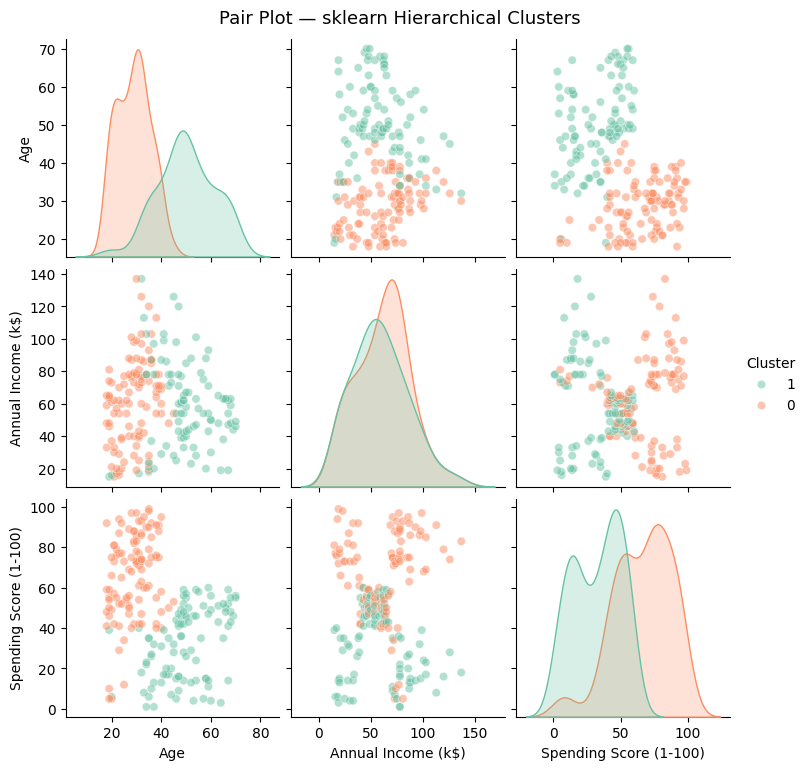

In [29]:
# ── 6c. Pair plot (first 5 features) ─────────────────────────
plot_cols = feat_cols[:5]     # Limit to 5 features for readability
pair_df   = df[plot_cols + ['Cluster']].copy()
pair_df['Cluster'] = pair_df['Cluster'].astype(str)
 
g = sns.pairplot(pair_df, hue='Cluster',
                 palette='Set2', plot_kws={'alpha': 0.5},
                 diag_kind='kde')
g.fig.suptitle("Pair Plot — sklearn Hierarchical Clusters",
               y=1.02, fontsize=13)
plt.savefig("sklearn_pairplot.png", dpi=120, bbox_inches='tight')
plt.show()
